In [1]:
# Przykład jak wczytać dane do ramki danych z użyciem biblioteki "pandas"
# a następnie narysować na wykresie punktowym przy użyciu biblioteki "matplotlib"

# Użyjemy zbioru danych "Advertising", który zawiera obserwacje o sprzedaży pewnego produktu na 200 rynkach
# wraz z budżetem reklamowym przeznaczonym na różne rodzaje mediów: TV, radio i prasę.
# Sprzedaż wyrażona jest w pewnych jednostkach sprzedaży. Budżet w jednostkach pieniężnych ($).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot

In [3]:
# możemy załadować dane w formacie CSV do naszej ramki danych (data frame) bezpośrednio z adresu HTTP.
# ponizej adres zbioru "Advertising" z repozytorium naszego kursu na githubie (https://github.com/mateuszr/ml-course-1)
df = pd.read_csv('https://raw.githubusercontent.com/mateuszr/ml-course-1/main/datasets/advertising.csv')

In [4]:
# Możemy załdować dane również w inny sposób: uploadując plik do notebooka (nalezy wybrać po lewej stronie ikonę "Files" -> "Upload")
# a nastepnie załadować plik w nastepujący sposób:
#df = pd.read_csv('advertising.csv')

# Trzeci sposób to skopiowanie pliku csv na dysk Google Drive (powiązany z tym samym kontem google).
# Wrzucamy plik do katalogu "Data" na naszym dysku Google Drive.
# Nastepnie trzeba zamontować dysk w tym notebooku (Ikonka "Files" -> "Mount Drive")
# na koncu mozna skopiowac plik z dysku Google Drive to notebooka za pomocą komendy:
#!cp /content/drive/MyDrive/Data/advertising.csv /content/

# Należy pamiętać, że za każdym razem kiedy wyjdziemy z notebooka to wszytskie dane które zuploadowaliśmy do notebooka przepadną.

In [5]:
# wydrukowanie informacji o ramce danych: ilość wierszy i kolumn
print("Size of the data:", df.shape)


Size of the data: (200, 4)


In [6]:
# wydrukowanie informacji o ramce danych: rodzaj kolumn oraz wartości

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
# podstawowe statystyki o ramce danych (dla każdej kolumny)

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
# wydrukowanie "nagłówka, w tym wypadku pierwszych 5 wierszy naszego zbioru danych"
# zauważmy, że nasz zbiór danych wejściowych posiadał nagłówek z nazwami kolumn i
# i biblioteka pandas odpowiednio to zinterpretowała, dzięki czemu nasza ramka danych posiada nazwy kolumn ("TV", "Radio"...)

df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [9]:
# Można też wprost wywołać taką ramkę danych (podając tylko nazwę zmiennej 'df').
# Zauważmy, że python nie zaleje nas całą zawartością data frame'a, ale inteligentnie przytnie wyświetloną ramkę do mniejszej ilości wierszy
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [10]:
# Na ramkach danych można używać tzw. slicingu ("wykrojów", "wycinków") czyli określić które wiersze chcemy wyświetlić
# Indeksowanie zaczyna się od 0. W tym przykładzie wybieramy elementy od 0 do 10 (wyłącznie, tj bez elementu 10)
df[0:10]

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [11]:
# Ramki danych w bibliotece pandas posiadają też specjalną składnię do wyboru kolumn
df["Sales"]

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9
...,...
195,7.6
196,14.0
197,14.8
198,25.5


In [12]:
# Można też wybrać kilka kolumn na raz, w tym celu przekazujemy listę (array) z nazwami kolumn: ["Sales", "TV"]
df[["Sales", "TV"]]

,Sales,TV
0,22.1,230.1
1,10.4,44.5
2,12.0,17.2
3,16.5,151.5
4,17.9,180.8
...,...,...
195,7.6,38.2
196,14.0,94.2
197,14.8,177.0
198,25.5,283.6


In [13]:
# składnia pozwalająca połączyć "slicing" z wyborem kolumn
df.loc[1:4, ["Sales", "TV"]]

,Sales,TV
1,10.4,44.5
2,12.0,17.2
3,16.5,151.5
4,17.9,180.8


Text(0.5, 1.0, 'Sales vs TV')

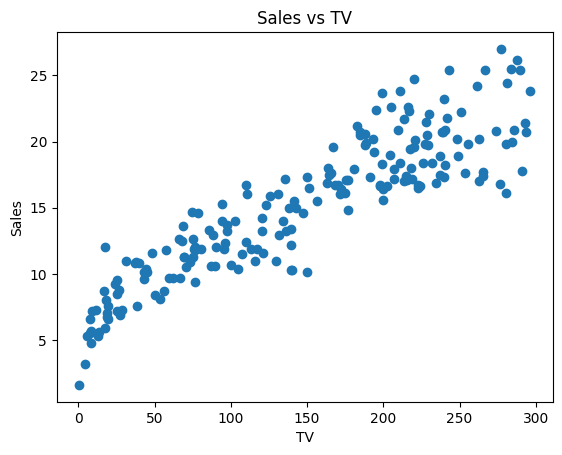

In [14]:
# rysowanie wykresu punktowego dla wynikow sprzedazy ("Sales") w zależności od nakładu na reklamę w TV
plot.scatter(df["TV"], df["Sales"])
# nazwy osi i nazwy wykresu
plot.xlabel("TV")
plot.ylabel("Sales")
plot.title("Sales vs TV")

Text(0.5, 1.0, 'Sales vs Newspaper')

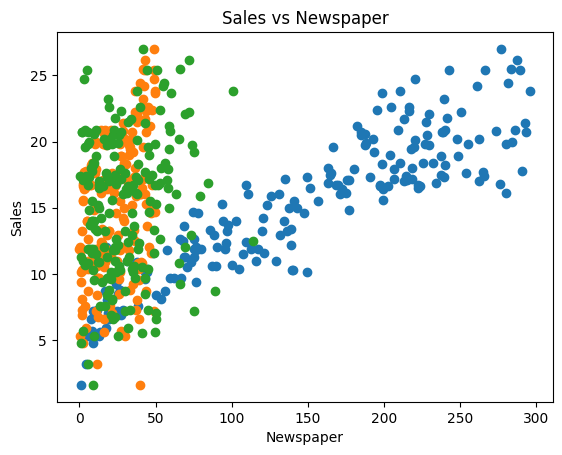

In [15]:
# połączenie 3 wykresów punktowych na jednym

# Wykres punktowy dla wynikow sprzedazy ("Sales") w zależności od nakładu na reklamę w TV
plot.scatter(df["TV"], df["Sales"])
plot.xlabel("TV")
plot.ylabel("Sales")
plot.title("Sales vs TV")

# wykres punktowy dla wynikow sprzedazy ("Sales") w zależności od nakładu na reklamę w radiu
plot.scatter(df["Radio"], df["Sales"])
plot.xlabel("Radio")
plot.ylabel("Sales")
plot.title("Sales vs Radio")

# wykres punktowy dla wynikow sprzedazy ("Sales") w zależności od nakładu na reklamę w prasie
plot.scatter(df["Newspaper"], df["Sales"])
plot.xlabel("Newspaper")
plot.ylabel("Sales")
plot.title("Sales vs Newspaper")


Text(0.5, 1.0, 'Sales vs Newspapers')

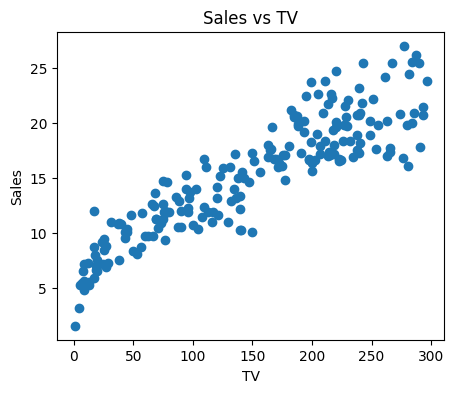

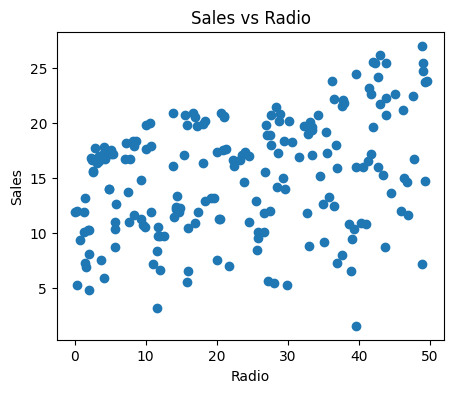

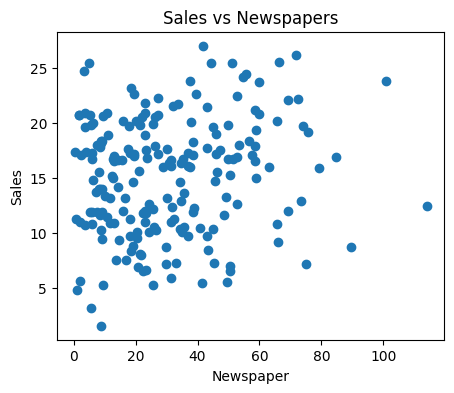

In [16]:
# 3 wykresy punktowe jeden po drugim
f, ax = plot.subplots(figsize=(5, 4))
plot.scatter(df["TV"], df["Sales"])
plot.xlabel("TV")
plot.ylabel("Sales")
plot.title("Sales vs TV")

f, ax = plot.subplots(figsize=(5, 4))
plot.scatter(df["Radio"], df["Sales"])
plot.xlabel("Radio")
plot.ylabel("Sales")
plot.title("Sales vs Radio")

f, ax = plot.subplots(figsize=(5, 4))
plot.scatter(df["Newspaper"], df["Sales"])
plot.xlabel("Newspaper")
plot.ylabel("Sales")
plot.title("Sales vs Newspapers")

In [ ]:
# Możemy również wyświetlić wykres punktowy dla każdej pary kolumn z naszej ramki danych ("Każdy z każdym").
# Ten sposób może być przydatny gdy chcemy szybko zerknąć na dane i poszukać gdzie są korelacje.

pd.plotting.scatter_matrix(df)
